## Train a Mask R-CNN model on dentex image data ##

Model description for the "mask_rcnn_X_101_32x8d_FPN_3x.yaml" model:

https://github.com/facebookresearch/detectron2/blob/main/MODEL_ZOO.md

Weights configuration file: 

configs/COCO-InstanceSegmentation/mask_rcnn_X_101_32x8d_FPN_3x.yaml

This notebooks requires the detectron2 library.

In [1]:
# Imports
import os
import numpy as np
import pandas as pd
import json
import glob
from matplotlib import pyplot as plt
from pathlib import Path

# Appearance of the Notebook
from IPython.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))
np.set_printoptions(linewidth=110)
pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 1000)

# PyTorch libraries
import torch

# Detectron2 library
import detectron2
from detectron2 import model_zoo
from detectron2.config import get_cfg
from detectron2.structures import BoxMode
from detectron2.utils.visualizer import Visualizer
from detectron2.data import MetadataCatalog, DatasetCatalog

# Import this module with autoreload
%load_ext autoreload
%autoreload 2
import computervision as dm
from computervision.imageproc import ImageData
from computervision.detector import Trainer
from computervision.inference import get_gpu_info

print(f'Project module version: {dm.__version__}')
print(f'Detectron2 version:     {detectron2.__version__}')

/usr/local/lib/python3.12/dist-packages/detectron2/model_zoo/model_zoo.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


Project module version: v0.0.2
Detectron2 version:     0.6


In [2]:
# GPU checks
device, device_str = get_gpu_info()
print()
print(f'Device for model training/inference: {device}')

CUDA available: True
Number of GPUs found:  1
Current device ID: 0
GPU device name:   NVIDIA GeForce RTX 3060 Laptop GPU
PyTorch version:   2.8.0a0+34c6371d24.nv25.08
CUDA version:      13.0
CUDNN version:     91200
Current device:    cuda:0

Device for model training/inference: cuda:0


In [3]:
# Path settings 
# Main data directory (defined as environment variable in docker-compose.yml)
data_root = os.environ.get('DATA_DIR')

# Download directory (change as needed)
dentex_dir = os.path.join(data_root, 'dentex')
model_dir = os.path.join(data_root, 'model')
data_dir = os.path.join(dentex_dir, 'dentex_detection')

# This image directory is where the xrays are in the archive, so should be left as-is
image_dir = os.path.join(data_dir, 'quadrant_enumeration', 'xrays')

# Directory for the output
output_dir = os.path.join(data_dir, 'output')

# Data frame with data splits 
data_df_file_name = 'dentex_detection_datasplit.parquet'
data_df_file = os.path.join(data_dir, data_df_file_name)

In [4]:
# Annotation files (and make sure the files are where they should be.
annotation_files = {}
dataset_list = ['train', 'val', 'test']
annotation_name_list = [f'dentex_detection_{dataset}.json' for dataset in dataset_list]
annotation_file_list = [os.path.join(data_dir, file_name) for file_name in annotation_name_list]
annotation_file_dict = dict(zip(dataset_list, annotation_file_list))
for dataset, annotation_file in annotation_file_dict.items():
    if not os.path.exists(annotation_file):
        raise FileNotFoundError(f'Annotation "{json_file}" not found.')
    else:
        annotation_files.update({dataset: annotation_file})
display(annotation_files)

{'train': '/app/data/dentex/dentex_detection/dentex_detection_train.json',
 'val': '/app/data/dentex/dentex_detection/dentex_detection_val.json',
 'test': '/app/data/dentex/dentex_detection/dentex_detection_test.json'}

### Register the dentex datasets ####

In [5]:
annotation_dict = {}
for dataset, annotation_file in annotation_file_dict.items():
    try:
        with open(annotation_file, 'r') as fl:
            annotations = json.load(fl)
    except FileNotFoundError:
        print(f'Annotation file not found: {annotation_file}')
        print('Make sure to run the annotations notebook.')
    else:
        annotation_dict.update({dataset: annotations})
        print(f'Loaded annotations for {len(annotations)} images for dataset "{dataset}".')

# Register the data sets
for dataset in dataset_list:
    dataset_name = f'dentex_{dataset}'
    if dataset_name not in DatasetCatalog:
        DatasetCatalog.register(name=dataset_name, func=lambda d=dataset: annotation_dict.get(d))
        MetadataCatalog.get(dataset_name).set(thing_classes=['tooth'])

Loaded annotations for 534 images for dataset "train".
Loaded annotations for 50 images for dataset "val".
Loaded annotations for 50 images for dataset "test".


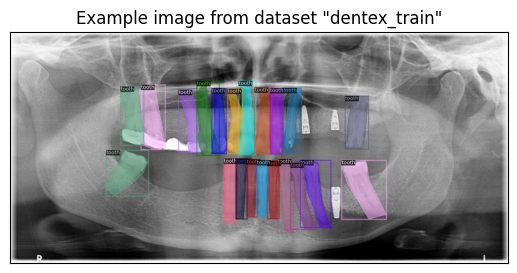

In [6]:
# Plot one image from the training set
def show_image(image, figsize=(3, 3), title=''):
    fig, ax = plt.subplots(figsize=figsize)
    ax.imshow(image)
    ax.set_title(title)
    ax.set(xticks=[], yticks=[])
    return fig, ax

# Load one random image from the training set
dataset = 'dentex_train'
image_list = DatasetCatalog.get(dataset)
image_dict = np.random.choice(image_list, size=1)[0]
metadata = MetadataCatalog.get(dataset)
im = ImageData().load_image(image_dict.get('file_name'))
vs = Visualizer(img_rgb=im, metadata=metadata, scale = 1.0)
vs = vs.draw_dataset_dict(image_dict).get_image()
fig, ax = show_image(vs, figsize=(12, 3), title=f'Example image from dataset "{dataset}"')
plt.show()

### Configure Faster R-CNN model for training ###

In [7]:
# Model definition
# For a description, see https://github.com/facebookresearch/detectron2/blob/main/MODEL_ZOO.md
# configs/COCO-InstanceSegmentation/mask_rcnn_X_101_32x8d_FPN_3x.yaml
# configs/COCO-InstanceSegmentation/mask_rcnn_R_101_FPN_3x.yaml
model_config = os.path.join('COCO-InstanceSegmentation', 'mask_rcnn_R_101_FPN_3x.yaml')

# Build configuration file
cfg = get_cfg()
cfg.merge_from_file(model_zoo.get_config_file(model_config))

# Output directory
model_name = 'Toothsegment'
model_version = 1
model_output_dir = os.path.join(model_dir, model_name, f'version_{model_version}')
Path(model_output_dir).mkdir(parents=True, exist_ok=True)

# Set the names for the datasets (as registered)
cfg.DATASETS.TRAIN = ('dentex_train', )
cfg.DATASETS.TEST = ('dentex_val', )
cfg.TEST.EVAL_PERIOD = 100
# The numbers of workers you can use depends on the number of cores and memory available per core
# Four workes is good for 32G memory
cfg.DATALOADER.NUM_WORKERS = 4
cfg.MODEL.WEIGHTS = model_zoo.get_checkpoint_url(model_config)
# The batch size needs to be adjusted according to the GPU memory
# A batch size of 4 works for and 8 GB GPU
cfg.SOLVER.IMS_PER_BATCH = 2
cfg.SOLVER.BASE_LR = 0.00025
cfg.SOLVER.STEPS = []
# Train for at least 3,000 iterations to get good results
cfg.SOLVER.MAX_ITER = 100
cfg.SOLVER.CHECKPOINT_PERIOD = 500
cfg.MODEL.ROI_HEADS.BATCH_SIZE_PER_IMAGE = 128
cfg.MODEL.ROI_HEADS.NUM_CLASSES = 1
cfg.OUTPUT_DIR = model_output_dir

# Train on GPU or CPU
cfg.MODEL.DEVICE = device.type

# Save the config file before training
model_config_file_name = f'{model_name}_{model_version}_config.yml'
model_config_file = os.path.join(model_output_dir, model_config_file_name)
with open(model_config_file, mode='w') as fl:
    fl.write(cfg.dump())

In [8]:
# Train the model
trainer = Trainer(cfg)
trainer.resume_or_load(resume=True)
trainer.train()

[11/06 14:56:54 d2.engine.defaults]: Model:
GeneralizedRCNN(
  (backbone): FPN(
    (fpn_lateral2): Conv2d(256, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral3): Conv2d(512, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output3): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral4): Conv2d(1024, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output4): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral5): Conv2d(2048, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output5): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (top_block): LastLevelMaxPool()
    (bottom_up): ResNet(
      (stem): BasicStem(
        (conv1): Conv2d(
          3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False
          (norm): FrozenBatchNorm2d(num_features=64, eps=1e-05)
        )
      )
      (res

/usr/local/lib/python3.12/dist-packages/torch/functional.py:554: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /opt/pytorch/pytorch/aten/src/ATen/native/TensorShape.cpp:4322.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


[11/06 14:57:02 d2.evaluation.evaluator]: Inference done 11/50. Dataloading: 0.0006 s/iter. Inference: 0.1679 s/iter. Eval: 0.4008 s/iter. Total: 0.5693 s/iter. ETA=0:00:22
[11/06 14:57:07 d2.evaluation.evaluator]: Inference done 21/50. Dataloading: 0.0008 s/iter. Inference: 0.1633 s/iter. Eval: 0.3695 s/iter. Total: 0.5337 s/iter. ETA=0:00:15
[11/06 14:57:12 d2.evaluation.evaluator]: Inference done 31/50. Dataloading: 0.0009 s/iter. Inference: 0.1595 s/iter. Eval: 0.3654 s/iter. Total: 0.5259 s/iter. ETA=0:00:09
[11/06 14:57:17 d2.evaluation.evaluator]: Inference done 42/50. Dataloading: 0.0009 s/iter. Inference: 0.1562 s/iter. Eval: 0.3530 s/iter. Total: 0.5101 s/iter. ETA=0:00:04
[11/06 14:57:21 d2.evaluation.evaluator]: Total inference time: 0:00:23.106260 (0.513472 s / iter per device, on 1 devices)
[11/06 14:57:21 d2.evaluation.evaluator]: Total inference pure compute time: 0:00:07 (0.155850 s / iter per device, on 1 devices)
[11/06 14:57:21 d2.evaluation.coco_evaluation]: Prepar